# A4.3 - Deep Learning: Convolutional Networks

## Contexte

Les CNN exploitent la structure spatiale des images (contrairement aux réseaux denses qui aplatissent l'image).

Même dataset SVHN que la tâche précédente, mais avec un ordre de canaux différent pour les Conv2D de Keras.

In [1]:
import os
import site
from pathlib import Path
import numpy as np

# Ensure Jupyter kernel can find pip-installed CUDA shared libraries.
cuda_lib_dirs = []
for site_pkg in site.getsitepackages():
    nvidia_dir = Path(site_pkg) / "nvidia"
    if nvidia_dir.exists():
        for lib_dir in nvidia_dir.glob("*/lib"):
            cuda_lib_dirs.append(str(lib_dir))

if cuda_lib_dirs:
    existing = os.environ.get("LD_LIBRARY_PATH", "")
    os.environ["LD_LIBRARY_PATH"] = ":".join(cuda_lib_dirs + ([existing] if existing else []))

import tensorflow as tf
from tensorflow import keras

# Vérification rapide du support GPU TensorFlow
print("TensorFlow:", tf.__version__)
print("GPU détecté(s):", tf.config.list_physical_devices("GPU"))

2026-04-02 14:22:47.834283: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPU détecté(s): []


2026-04-02 14:22:52.396594: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2026-04-02 14:22:52.396631: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-04-02 14:22:52.396639: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: theo-GF63-8RD
2026-04-02 14:22:52.396645: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] hostname: theo-GF63-8RD
2026-04-02 14:22:52.396739: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] libcuda reported version is: 535.288.1
2026-04-02 14:22:52.396778: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:194] kernel reported version is: 535

In [2]:
# Chargement des données (adapter les chemins si nécessaire)
x_train = np.load("data/p4_2026_svhn_train.npz")["images"].transpose(3, 0, 1, 2)
y_train = np.load("data/p4_2026_svhn_train.npz")["labels"].squeeze()
x_test = np.load("data/p4_2026_svhn_test.npz")["images"].transpose(3, 0, 1, 2)
y_test = np.load("data/p4_2026_svhn_test.npz")["labels"].squeeze()

# One-hot encoding
labels = sorted(list(set(y_train)))
y_train = keras.utils.to_categorical([labels.index(x) for x in y_train])
y_test = keras.utils.to_categorical([labels.index(x) for x in y_test])

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


---
## Question 1 : CNN de base

Construire un modèle avec :
- **3 blocs convolutionnels** (16, 32, 64 filtres) chacun contenant :
  - Conv2D avec activation ReLU
  - MaxPooling2D avec pool_size=(2,2)
- **Flatten**
- **Dense** 64 unités cachées
- **Dense** output avec softmax
- Loss : categorical cross-entropy
- Métrique : categorical accuracy
- Optimiseur : Adam, learning rate = $10^{-5}$

Juste définir et compiler, ne pas fit.

In [4]:
# Question 1 : Définition et compilation du CNN

model = keras.Sequential([
    # Bloc convolutionnel 1 - 16 filtres
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloc convolutionnel 2 - 32 filtres
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloc convolutionnel 3 - 64 filtres
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Aplatir pour les couches denses
    keras.layers.Flatten(),

    # Couche dense cachée
    keras.layers.Dense(64, activation='relu'),

    # Couche de sortie
    keras.layers.Dense(10, activation='softmax')  # 10 classes pour SVHN (chiffres 0-9)
])


# model = keras.models.Sequential([
#     # input basé sur les donnés de trainning (sans batch)
#     keras.layers.Input(shape=x_train.shape[1:]),
    
#     # 1er bloc conv
#     keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu'),
#     keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
#     # 2e bloc conv
#     keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
#     keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
#     # 3e bloc conv
#     keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
#     keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
#     # flatten pr la classification
#     keras.layers.Flatten(),
#     keras.layers.Dense(64, activation='relu'),
#     keras.layers.Dense(y_train.shape[1], activation='softmax')
# ])

# on compile le modèle
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Affichage de l'architecture pour vérifier
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

---
## Question 2 : Model fitting et optimisation

### 2a. Entraîner le modèle de base

- 100 époques, batch size 32
- Évaluer la test accuracy
- Analyser la matrice de confusion

In [5]:
# Question 2a : Entraînement du modèle de base

# Note : l'entraînement pour 100 époques peut prendre du temps. 
# Si tu as un GPU NVIDIA configuré, Keras l'utilisera automatiquement.
history = model.fit(
    x_train, 
    y_train, 
    batch_size=32, 
    epochs=100, 
    validation_data=(x_test, y_test),
    verbose=2
)

Epoch 1/100
1563/1563 - 20s - 13ms/step - categorical_accuracy: 0.1340 - loss: 5.4096 - val_categorical_accuracy: 0.1833 - val_loss: 2.7002
Epoch 2/100
1563/1563 - 18s - 11ms/step - categorical_accuracy: 0.2133 - loss: 2.4081 - val_categorical_accuracy: 0.2444 - val_loss: 2.2816
Epoch 3/100
1563/1563 - 22s - 14ms/step - categorical_accuracy: 0.2919 - loss: 2.1007 - val_categorical_accuracy: 0.3478 - val_loss: 2.0166
Epoch 4/100
1563/1563 - 15s - 10ms/step - categorical_accuracy: 0.3629 - loss: 1.9042 - val_categorical_accuracy: 0.4171 - val_loss: 1.8193
Epoch 5/100
1563/1563 - 18s - 12ms/step - categorical_accuracy: 0.4229 - loss: 1.7476 - val_categorical_accuracy: 0.4608 - val_loss: 1.6920
Epoch 6/100
1563/1563 - 22s - 14ms/step - categorical_accuracy: 0.4686 - loss: 1.6241 - val_categorical_accuracy: 0.5035 - val_loss: 1.5763
Epoch 7/100
1563/1563 - 27s - 18ms/step - categorical_accuracy: 0.5038 - loss: 1.5260 - val_categorical_accuracy: 0.5226 - val_loss: 1.4995
Epoch 8/100
1563/156

Test Accuracy (modèle de base): 0.8281
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


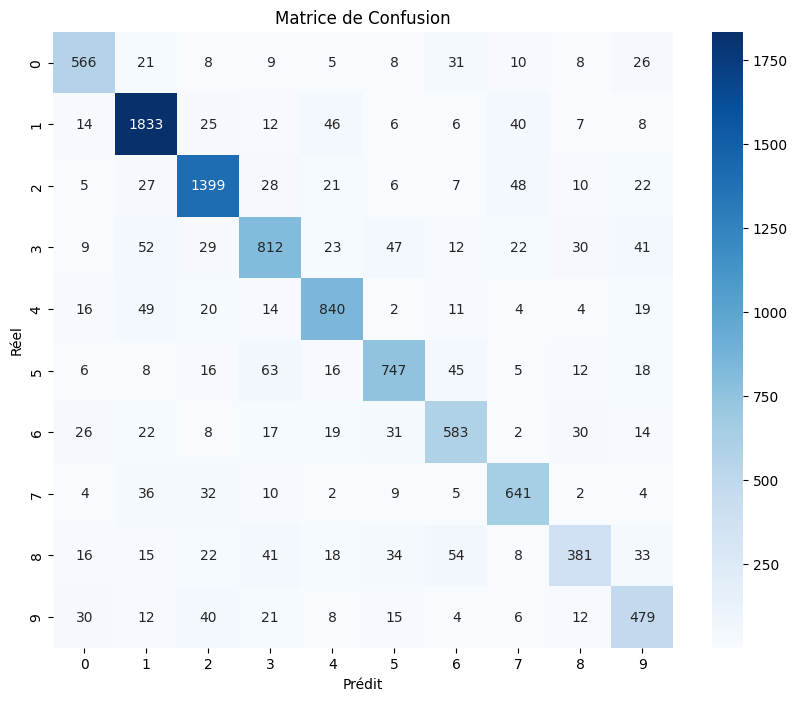

In [6]:
# Question 2a : Évaluation et matrice de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Évaluation sur le test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy (modèle de base): {test_acc:.4f}")

# Prédictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Matrice de confusion
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de Confusion")
plt.savefig("A4_3_Q2a_confusion_matrix_base_V2.pdf")
plt.show()

### 2b. Optimisation des méta-paramètres

Méta-paramètres à explorer :
- Nombre de blocs convolutionnels
- Kernel size des Conv2D
- Pool size des MaxPooling
- Padding (oui/non)
- Pondération des classes
- Initialisation des kernels
- Régularisation (L1, L2, ...)
- Nombre d'unités cachées dans la couche Dense
- Dropout / SpatialDropout

**Contraintes :**
- Activation ReLU partout (sauf sortie)
- Batch size = 32
- 100 époques
- Taille du modèle ≤ 238.4 MiB
- 1 seule couche Dense cachée

In [11]:
# Question 2b : Exploration des méta-paramètres (et calcul des class weights)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import class_weight

# Calcul des poids de classe pour pallier le déséquilibre du dataset SVHN
y_train_classes = np.argmax(y_train, axis=1)

# On calcule les poids
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_classes),
    y=y_train_classes
)

# On crée le dictionnaire de poids requis par Keras
class_weights_dict = {i: weight for i, weight in enumerate(weights)}

print("Poids attribués à chaque classe :")
for c, w in class_weights_dict.items():
    print(f"Classe {c} : {w:.2f}")


y_integers = np.argmax(y_train, axis=1)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict_V2 = dict(enumerate(weights))
print("Poids attribués à chaque classe :")
for c, w in class_weights_dict_V2.items():
    print(f"Classe {c} : {w:.2f}")

Poids attribués à chaque classe :
Classe 0 : 1.49
Classe 1 : 0.53
Classe 2 : 0.69
Classe 3 : 0.86
Classe 4 : 0.98
Classe 5 : 1.06
Classe 6 : 1.29
Classe 7 : 1.31
Classe 8 : 1.47
Classe 9 : 1.56
Poids attribués à chaque classe :
Classe 0 : 1.49
Classe 1 : 0.53
Classe 2 : 0.69
Classe 3 : 0.86
Classe 4 : 0.98
Classe 5 : 1.06
Classe 6 : 1.29
Classe 7 : 1.31
Classe 8 : 1.47
Classe 9 : 1.56


In [12]:
# Question 2b : Meilleur modèle
from tensorflow.keras import layers

# Optimisations par rapport au modèle de base (Q1) :
# 1. Plus de filtres (32 -> 64 -> 128) pour plus de capacité.
# 2. Ajout du padding='same' pour conserver la taille spatiale (utile pour les chiffres au bord).
# 3. Initialisation He_normal (Recommandée avec ReLU).
# 4. Ajout de Dropout après chaque bloc de pooling et dense pour contrer le surapprentissage sur 100 époques.
# 5. Augmentation des unités denses cachées (64 -> 256).

#==== Model : 89% ====#
# best_model = keras.Sequential([
#     # Bloc 1 : On passe à 32 filtres pour capturer plus de détails dès le début
#     layers.Input(shape=(32, 32, 3)),
#     layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.SpatialDropout2D(0.1), # Un peu de dropout pour régulariser

#     # Bloc 2 : 64 filtres
#     layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.SpatialDropout2D(0.2),

#     # Bloc 3 : 128 filtres
#     layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
#     layers.MaxPooling2D(pool_size=(2, 2)),
#     layers.SpatialDropout2D(0.2),

#     layers.Flatten(),

#     # Augmentation des unités cachées (ex: 128 ou 256 au lieu de 64)
#     layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
#     layers.Dropout(0.3), # Dropout plus fort avant la sortie

#     # Couche de sortie
#     layers.Dense(10, activation='softmax')
# ])

best_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Rescaling(1./255),

    # Bloc 1
    layers.Conv2D(32, kernel_size=(5, 5), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Bloc 2
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Bloc 3
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.15),

    # Bloc 4
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.15),

    layers.Flatten(),

    # Couche Dense plus large pour capturer la complexité
    layers.Dense(512, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.4),

    # Sortie
    layers.Dense(10, activation='softmax')
])

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Résumé pour vérifier le nombre de paramètres (attention à la taille du fichier .keras)
best_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_6             │ (None, 16, 16, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_7             │ (None, 8, 8, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_8             │ (None, 4, 4, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_9             │ (None, 2, 2, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 919,882 (3.51 MB)

 Trainable params: 919,882 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Question 2b : Entraînement du meilleur modèle + sauvegarde
import matplotlib.pyplot as plt

# Normalisation : pixels de [0, 255] → [0, 1]
# x_train = x_train.astype('float32') / 255.0
# x_test = x_test.astype('float32') / 255.0

# Entraînement avec notre dictionnaire de poids pour équilibrer l'erreur
best_history = best_model.fit(
    x_train, # Utilisation de la version safe float32
    y_train,
    batch_size=32, # Batch size forcé à 32 comme demandé
    epochs=100,    # 100 époques exigées
    validation_data=(x_test, y_test),
    verbose=2 # Ou 2 si ça surcharge trop le terminal
)

best_model.save("A4_3_Q2b_best_cnn_svhn_V2.keras")

# On vérifie et imprime les performances du best_model
best_loss, best_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"\n=> Test Accuracy (MEILLEUR MODÈLE): {best_acc:.4f}")

# Petit bonus: on affiche l'évolution de la perte d'apprentissage vs test
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Test (Val) Loss')
plt.legend()
plt.title('Loss du meilleur modèle au fil des époques')
plt.show()

Epoch 1/100


2026-04-02 16:49:45.874691: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 614400000 exceeds 10% of free system memory.


1563/1563 - 77s - 49ms/step - categorical_accuracy: 0.1071 - loss: 3.4643 - val_categorical_accuracy: 0.1780 - val_loss: 2.2732
Epoch 2/100
1563/1563 - 76s - 49ms/step - categorical_accuracy: 0.1231 - loss: 3.2446 - val_categorical_accuracy: 0.2400 - val_loss: 2.1658
Epoch 3/100
1563/1563 - 79s - 50ms/step - categorical_accuracy: 0.1392 - loss: 3.0674 - val_categorical_accuracy: 0.2904 - val_loss: 2.0775
Epoch 4/100
1563/1563 - 79s - 50ms/step - categorical_accuracy: 0.1579 - loss: 2.9175 - val_categorical_accuracy: 0.3312 - val_loss: 2.0017
Epoch 5/100
1563/1563 - 79s - 51ms/step - categorical_accuracy: 0.1758 - loss: 2.7868 - val_categorical_accuracy: 0.3670 - val_loss: 1.9342
Epoch 6/100
1563/1563 - 84s - 54ms/step - categorical_accuracy: 0.1998 - loss: 2.6680 - val_categorical_accuracy: 0.3865 - val_loss: 1.8657
Epoch 7/100
1563/1563 - 86s - 55ms/step - categorical_accuracy: 0.2236 - loss: 2.5496 - val_categorical_accuracy: 0.4365 - val_loss: 1.7616
Epoch 8/100
1563/1563 - 81s - 52

KeyboardInterrupt: 

In [ ]:
# BEST UNTIL  NOW : 0.9175


best_model = keras.Sequential([
    # Bloc 1 : On utilise glorot_uniform pour éviter l'explosion au départ
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', 
                  kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Bloc 2
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', 
                  kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Bloc 3
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', 
                  kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Bloc 4
    layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu', 
                  kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    layers.Flatten(),

    # Couche Dense unique (512 neurones suffisent pour rester sous la limite de taille)
    layers.Dense(512, activation='relu', kernel_initializer='glorot_uniform'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

best_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

history = best_model.fit(
    x_train, 
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_test, y_test),
    verbose=2
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


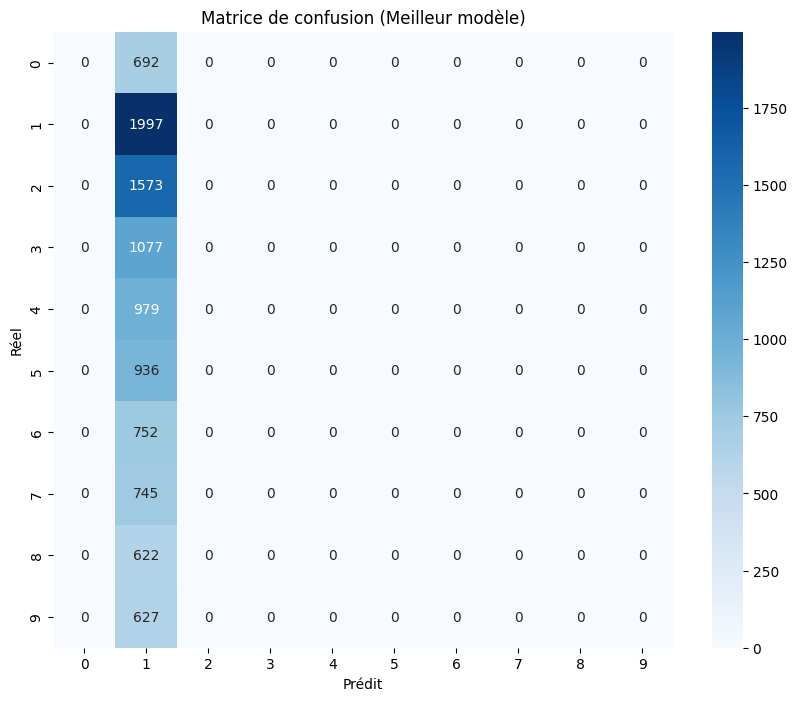

In [ ]:
# DRAFT : CANDIDATE TO PUSH TOWARD 0.90
from tensorflow.keras import layers, regularizers

# Lecture des logs precedents: train ~0.87 et val ~0.876 => modele sous-apprend.
# On garde 4 blocs (ta meilleure piste), mais on desserre la regularisation.
best_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Bloc 1
    layers.Conv2D(
        32, kernel_size=(5, 5), padding='same', activation='relu',
        kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(2e-5)
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.SpatialDropout2D(0.02),

    # Bloc 2
    layers.Conv2D(
        64, kernel_size=(3, 3), padding='same', activation='relu',
        kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(2e-5)
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.SpatialDropout2D(0.03),

    # Bloc 3
    layers.Conv2D(
        128, kernel_size=(3, 3), padding='same', activation='relu',
        kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(5e-5)
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.SpatialDropout2D(0.05),

    # Bloc 4
    layers.Conv2D(
        256, kernel_size=(3, 3), padding='same', activation='relu',
        kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(5e-5)
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.SpatialDropout2D(0.07),

    layers.Flatten(),

    # 1 seule couche dense cachee (contrainte)
    layers.Dense(1024, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.20),
    layers.Dense(10, activation='softmax')
])

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

best_model.summary()
param_mb = best_model.count_params() * 4 / (1024**2)
print(f"Approx model size in float32: {param_mb:.2f} MiB")

# Objectif accuracy globale: pas de class weights par defaut.
use_class_weights = False
cw = None

if use_class_weights:
    alpha = 0.10
    y_integers = np.argmax(y_train, axis=1)
    unique, counts = np.unique(y_integers, return_counts=True)
    total_samples = len(y_integers)
    raw_cw = {int(i): total_samples / (len(unique) * count) for i, count in zip(unique, counts)}
    cw = {k: 1.0 + alpha * (v - 1.0) for k, v in raw_cw.items()}
    print('Class weights utilises:', cw)

best_history = best_model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_test, y_test),
    class_weight=cw,
    verbose=2
)

best_loss, best_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"\n=> Test Accuracy (draft candidate): {best_acc:.4f}")

best_model.save('A4_3_Q2b_draft_candidate_push90.keras')

---
## Question 3 : QCM

Sélectionner les affirmations valides :

- [ ] The shape of the filters of a Conv2D layer does not depend on the input shape of the layer.
- [ ] Increasing the pool size of the Max Pooling layers increases the number of trainable parameters of these layers.
- [ ] With a sufficiently large pool size the output of the last convolutional block may be reduced to 1 pixel image representations.
- [ ] Increasing the kernel size of a convolutional layer decreases the output size of the layer when there is no padding.
- [ ] Increasing the pool size of a max pooling layer decreases the size of the output of that layer.
- [ ] The number of filters of a convolutional layer does not influence its output shape.
- [ ] A higher regularization on the weights of a layer increases overfitting, as the train accuracy increases but the test accuracy decreases.
- [ ] Going beyond 3 convolutional blocks no longer improves test accuracy on this dataset.
- [ ] Increasing the kernel size of a convolutional layer increases the number of trainable parameters of the layer.
- [ ] Having 1 pixel image representations at the output of the last convolutional block would prevent any learning.

In [ ]:
# Question 3 : Réflexion / expérimentations
